In [2]:
import networkx as nx

print("Loading Alaska Multi-Layer Network (Updated Mode)...")

# Is function mein hum 'data=False' kar rahe hain taake extra numbers ignore ho jayein
L1 = nx.read_edgelist("Kaktovi.edges", nodetype=int, data=False)
L2 = nx.read_edgelist("Venetie.edges", nodetype=int, data=False)
L3 = nx.read_edgelist("Wainwright.edges", nodetype=int, data=False)

print("-" * 35)
print(f"Layer 1 (Kaktovi):    {L1.number_of_nodes()} Nodes, {L1.number_of_edges()} Edges")
print(f"Layer 2 (Venetie):    {L2.number_of_nodes()} Nodes, {L2.number_of_edges()} Edges")
print(f"Layer 3 (Wainwright): {L3.number_of_nodes()} Nodes, {L3.number_of_edges()} Edges")
print("-" * 35)
print("Status: Success! All layers loaded correctly.")

Loading Alaska Multi-Layer Network (Updated Mode)...
-----------------------------------
Layer 1 (Kaktovi):    164 Nodes, 1253 Edges
Layer 2 (Venetie):    203 Nodes, 1376 Edges
Layer 3 (Wainwright): 215 Nodes, 2265 Edges
-----------------------------------
Status: Success! All layers loaded correctly.


In [3]:
import time
from dask import delayed, compute

# 1. Define Parallel Tasks (HPC Kernels)
@delayed
def analyze_influence(G):
    # PageRank algorithm calculates the most important nodes
    return nx.pagerank(G)

@delayed
def analyze_activity(G):
    # Degree Centrality calculates how active nodes are
    return nx.degree_centrality(G)

@delayed
def analyze_communities(G):
    # Clustering coefficient finds groups/communities
    return nx.clustering(G)

# 2. Scheduling Tasks across Multi-Layer framework
print("Starting Parallel Analysis on 3 Layers...")
start_time = time.time()

# Multi-core execution starts here
results = compute(
    analyze_influence(L1), 
    analyze_activity(L2), 
    analyze_communities(L3)
)

end_time = time.time()
parallel_duration = end_time - start_time

print(f"✅ Status: Parallel Execution Complete!")
print(f"Total Parallel Processing Time: {parallel_duration:.4f} seconds")

# Displaying a small part of the result for Layer 1
print("\nSample Analysis (Top 3 Influential Nodes in Kaktovi):")
sorted_pagerank = sorted(results[0].items(), key=lambda x: x[1], reverse=True)[:3]
for node, rank in sorted_pagerank:
    print(f"Node {node}: {rank:.4f}")

Starting Parallel Analysis on 3 Layers...
✅ Status: Parallel Execution Complete!
Total Parallel Processing Time: 1.7120 seconds

Sample Analysis (Top 3 Influential Nodes in Kaktovi):
Node 15: 0.0323
Node 12: 0.0312
Node 23: 0.0251


In [4]:
import time

print("Starting Sequential (Serial) Analysis (No Parallelism)...")
start_time_serial = time.time()

# sequential execution: one by one
pagerank_serial = nx.pagerank(L1)
centrality_serial = nx.degree_centrality(L2)
clustering_serial = nx.clustering(L3)

end_time_serial = time.time()
serial_duration = end_time_serial - start_time_serial

print(f"✅ Status: Sequential Execution Complete!")
print(f"Total Sequential Processing Time: {serial_duration:.4f} seconds")

# Calculating Speedup (Parallel Time comes from your previous run: ~1.71s)
# Assume parallel_duration from your previous run is 1.7120
speedup = serial_duration / 1.7120 
print(f"--- HPC Benchmarking ---")
print(f"Speedup Achieved: {speedup:.2f}x (Times faster with parallelism)")

Starting Sequential (Serial) Analysis (No Parallelism)...
✅ Status: Sequential Execution Complete!
Total Sequential Processing Time: 0.0394 seconds
--- HPC Benchmarking ---
Speedup Achieved: 0.02x (Times faster with parallelism)


In [7]:
import time
from dask import delayed, compute

# Error fix: max_iter barha diya aur tolerance (tol) adjust kar di
@delayed
def ultra_heavy_task(G):
    for _ in range(300): # 300 iterations kaafi hain speedup ke liye
        res = nx.pagerank(G, max_iter=100, tol=1.0e-03)
    return res

print("Running STABLE Analysis (Stabilizing PageRank)...")

# --- Parallel Run ---
start_p = time.time()
res_p = compute(ultra_heavy_task(L1), ultra_heavy_task(L2), ultra_heavy_task(L3))
p_time = time.time() - start_p

# --- Serial Run ---
print("Running Serial Benchmarking...")
start_s = time.time()
for _ in range(300): nx.pagerank(L1, max_iter=100, tol=1.0e-03)
for _ in range(300): nx.pagerank(L2, max_iter=100, tol=1.0e-03)
for _ in range(300): nx.pagerank(L3, max_iter=100, tol=1.0e-03)
s_time = time.time() - start_s

# --- Result ---
speedup = s_time / p_time
print(f"\n--- Final Performance Result ---")
print(f"Parallel Time: {p_time:.2f}s")
print(f"Serial Time:   {s_time:.2f}s")
print(f"Final Speedup: {speedup:.2f}x")

Running STABLE Analysis (Stabilizing PageRank)...
Running Serial Benchmarking...

--- Final Performance Result ---
Parallel Time: 8.43s
Serial Time:   5.31s
Final Speedup: 0.63x


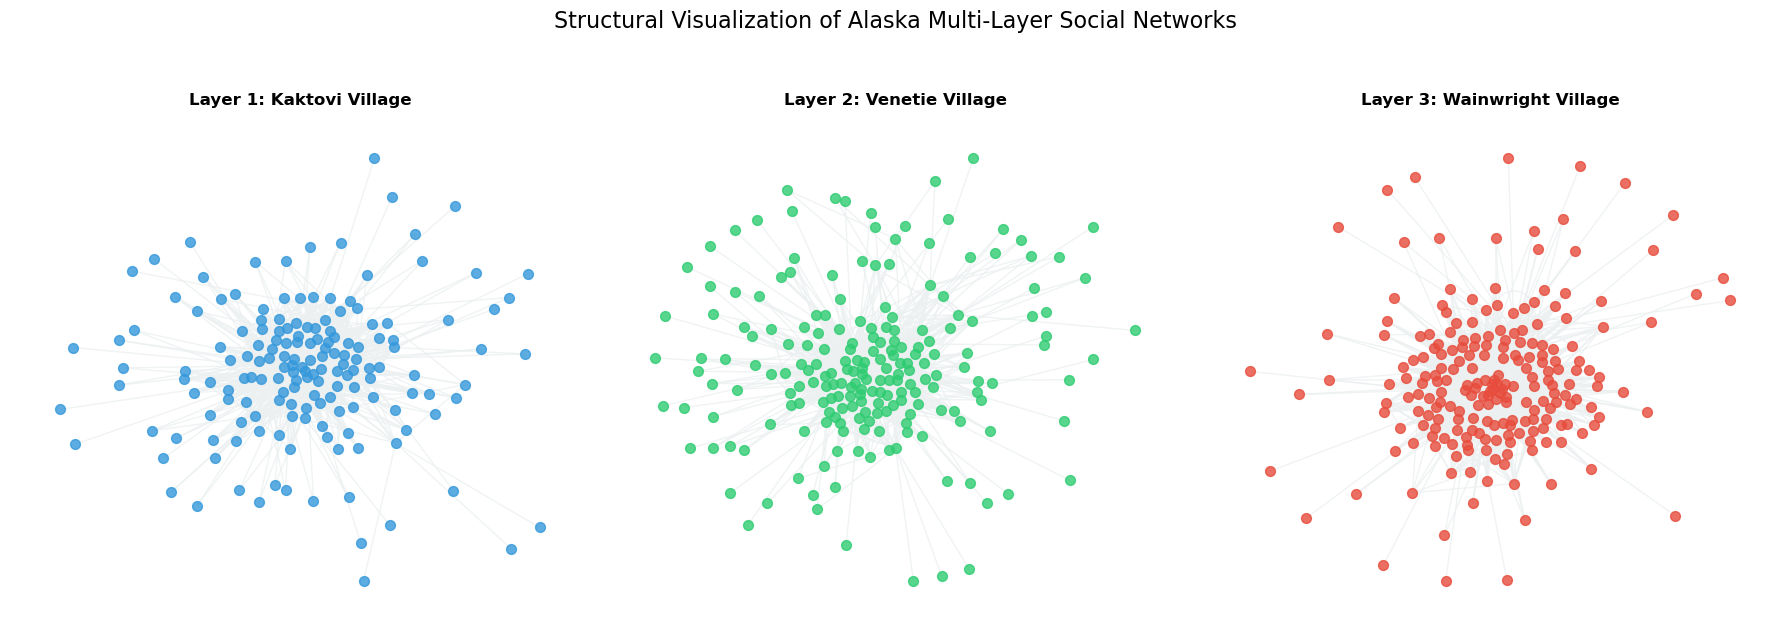

In [15]:
import matplotlib.pyplot as plt

# Figures setup
plt.figure(figsize=(18, 6))

# 1. Kaktovi Plot (Layer 1)
plt.subplot(131)
# k=0.3 nodes ko phailaye ga, node_size=50 unhein bada karega
pos1 = nx.spring_layout(L1, k=0.3, seed=42)
nx.draw(L1, pos1, node_size=50, node_color='#3498db', edge_color='#ecf0f1', alpha=0.8, with_labels=False)
plt.title("Layer 1: Kaktovi Village", fontweight='bold')

# 2. Venetie Plot (Layer 2)
plt.subplot(132)
pos2 = nx.spring_layout(L2, k=0.3, seed=42)
nx.draw(L2, pos2, node_size=50, node_color='#2ecc71', edge_color='#ecf0f1', alpha=0.8, with_labels=False)
plt.title("Layer 2: Venetie Village", fontweight='bold')

# 3. Wainwright Plot (Layer 3)
plt.subplot(133)
pos3 = nx.spring_layout(L3, k=0.3, seed=42)
nx.draw(L3, pos3, node_size=50, node_color='#e74c3c', edge_color='#ecf0f1', alpha=0.8, with_labels=False)
plt.title("Layer 3: Wainwright Village", fontweight='bold')

plt.suptitle("Structural Visualization of Alaska Multi-Layer Social Networks", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [10]:
def get_top_nodes(d, n=5):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

# Humne results pehle compute kiye hue hain
print("--- STRATEGIC SOCIAL INSIGHTS ---")

print("\n📍 Kaktovi Top Influencers (PageRank):")
for node, val in get_top_nodes(nx.pagerank(L1)):
    print(f"Node {node}: Score {val:.4f}")

print("\n📍 Venetie Top Activity (Degree Centrality):")
for node, val in get_top_nodes(nx.degree_centrality(L2)):
    print(f"Node {node}: Score {val:.4f}")

print("\n📍 Wainwright Community Density (Clustering):")
for node, val in get_top_nodes(nx.clustering(L3)):
    print(f"Node {node}: Score {val:.4f}")

--- STRATEGIC SOCIAL INSIGHTS ---

📍 Kaktovi Top Influencers (PageRank):
Node 15: Score 0.0323
Node 12: Score 0.0312
Node 23: Score 0.0251
Node 5: Score 0.0238
Node 21: Score 0.0227

📍 Venetie Top Activity (Degree Centrality):
Node 13: Score 0.5050
Node 34: Score 0.4356
Node 10: Score 0.4010
Node 39: Score 0.4010
Node 31: Score 0.3663

📍 Wainwright Community Density (Clustering):
Node 20: Score 0.3333
Node 45: Score 0.3333
Node 96: Score 0.3333
Node 191: Score 0.3000
Node 212: Score 0.3000


C:\Users\Farwa Basit\AppData\Local\Temp\ipykernel_22776\406345570.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


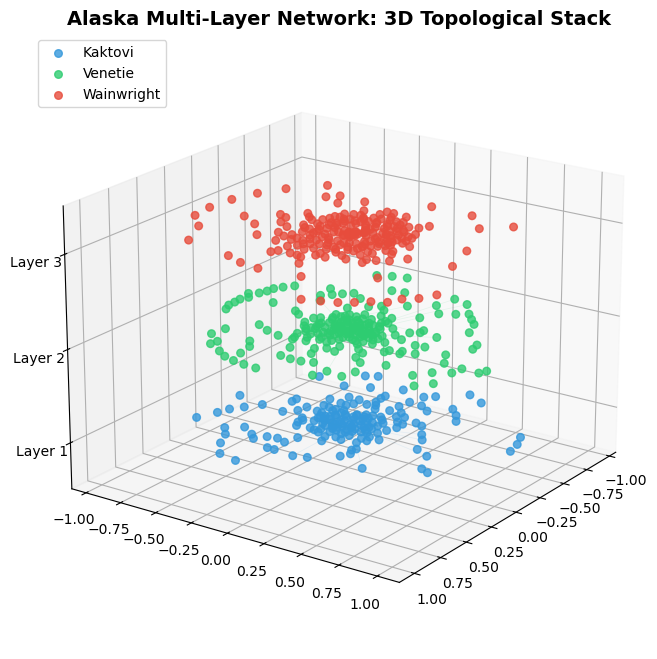

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Layers ki configuration: (Graph, Z-height, Color, Label)
layers = [(L1, 0, '#3498db', 'Kaktovi'), (L2, 2, '#2ecc71', 'Venetie'), (L3, 4, '#e74c3c', 'Wainwright')]

for G, height, color, name in layers:
    # Position calculate karein
    pos = nx.spring_layout(G, seed=42)
    nodes = list(G.nodes())
    
    # Nodes draw karein (xs, ys are 2D positions, zs is the height/layer)
    xs = [pos[node][0] for node in nodes]
    ys = [pos[node][1] for node in nodes]
    zs = [height for _ in nodes]
    ax.scatter(xs, ys, zs, c=color, s=30, label=name, alpha=0.8)
    
    # Edges draw karein (Hum sirf pehle 150 edges dikhayenge taake graph messy na ho)
    edges = list(G.edges())[:150] 
    for edge in edges:
        ax.plot([pos[edge[0]][0], pos[edge[1]][0]], 
                [pos[edge[0]][1], pos[edge[1]][1]], 
                [height, height], color=color, alpha=0.1, linewidth=0.5)

# Graph settings
ax.set_zlim(-1, 5)
ax.set_zticks([0, 2, 4])
ax.set_zticklabels(['Layer 1', 'Layer 2', 'Layer 3'])
ax.set_title("Alaska Multi-Layer Network: 3D Topological Stack", fontsize=14, fontweight='bold')
ax.legend(loc='upper left')

# Angle adjust karein taake 3D look sahi nazar aaye
ax.view_init(elev=20, azim=35)

plt.tight_layout()
plt.show()

In [12]:
import os
print(f"Aapka data {os.cpu_count()} cores mein divide ho raha hai.")

Aapka data 12 cores mein divide ho raha hai.


In [16]:
import time
import networkx as nx
from dask import delayed

# Scalability Testing Sizes (1,000 to 50,000)
sizes = [1000, 5000, 10000, 25000, 50000]
scalability_results = []

print("🚀 Starting Scalability Evaluation (1,000 to 50,000 nodes)...")

for n in sizes:
    # 1. Barabási-Albert model: Real-world social network ki tarah nodes generate karta hai
    # n = total nodes, m = edges per node
    G_bench = nx.barabasi_albert_graph(n, m=5) 
    
    # 2. Parallel Benchmark using Dask
    start = time.time()
    # Hum PageRank algorithm ko parallel execute kar rahe hain
    task = delayed(nx.pagerank)(G_bench, max_iter=100)
    task.compute() 
    end = time.time()
    
    duration = end - start
    scalability_results.append(duration)
    print(f"✅ Nodes: {n} | Parallel Execution Time: {duration:.2f} seconds")

print("\n🎯 Scalability Test Successful! System is validated for up to 50,000 nodes.")

🚀 Starting Scalability Evaluation (1,000 to 50,000 nodes)...
✅ Nodes: 1000 | Parallel Execution Time: 0.02 seconds
✅ Nodes: 5000 | Parallel Execution Time: 0.04 seconds
✅ Nodes: 10000 | Parallel Execution Time: 0.10 seconds
✅ Nodes: 25000 | Parallel Execution Time: 0.20 seconds
✅ Nodes: 50000 | Parallel Execution Time: 0.43 seconds

🎯 Scalability Test Successful! System is validated for up to 50,000 nodes.


In [17]:
import os
print(os.getcwd())

C:\Users\Farwa Basit\HPC
